# Dask quickstart — `Dataset`

A single raster, read lazily. `read_array(chunks=...)` returns a `dask.array` instead of
a NumPy array; you compose a graph and materialise it once with `.compute()`. For the full
surface (neighbourhood ops, DEM derivatives, zonal stats) see `lazy-dataset-complete`.

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

import dask.array as da
import numpy as np

DATA = Path('../../../examples/data')
DATA.is_dir()

True

## Eager vs lazy reads

In [2]:
from pyramids.base.protocols import as_numpy, is_lazy
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'acc4000.tif')
ds.shape, ds.cell_size, ds.epsg

((1, 13, 14), 4000.0, 32618)

`ds` is a concrete `Dataset`. Plotting band 0 shows the flow-accumulation raster the lazy
`read_array(chunks=...)` calls below operate on.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


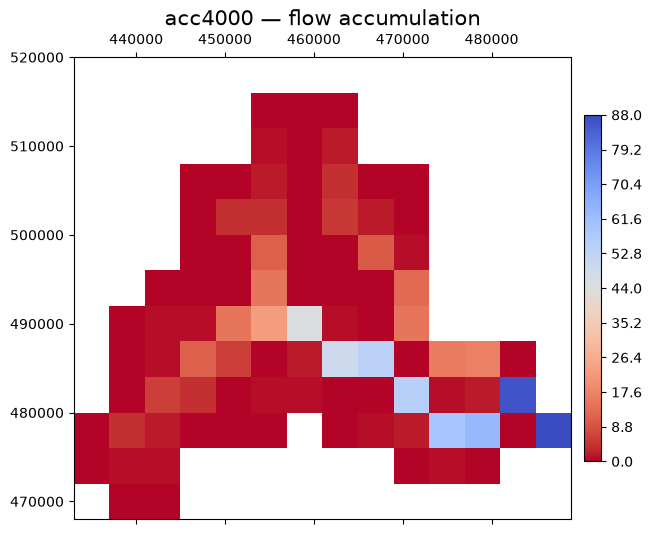

In [3]:
ds.plot(band=0, title="acc4000 — flow accumulation")

In [4]:
eager = ds.read_array()  # numpy.ndarray
lazy = ds.read_array(chunks=(32, 32))  # dask.array.Array — no I/O yet
(type(eager).__name__, is_lazy(eager)), (type(lazy).__name__, is_lazy(lazy))

(('ndarray', False), ('Array', True))

## Build a graph, then compute once

In [5]:
# Mask the nodata sentinel in the graph before reducing.
nodata = ds.no_data_value[0]
masked = da.where(lazy == nodata, np.nan, lazy)
stats = {
    'min': float(da.nanmin(masked).compute()),
    'max': float(da.nanmax(masked).compute()),
    'mean': float(da.nanmean(masked).compute()),
}
stats

{'min': 0.0, 'max': 88.0, 'mean': 7.966291904449463}

In [6]:
# as_numpy is a no-op on numpy and forces a compute on dask.
materialised = as_numpy(lazy)
type(materialised).__name__, materialised.shape

('ndarray', (13, 14))

## Parallel writes — `to_zarr` / `from_zarr`

Zarr is the only lazy-parallel write path for rasters: each chunk becomes an independent
file, so workers write concurrently. Re-open with `chunks=` to stay lazy.

In [7]:
import tempfile

store = Path(tempfile.mkdtemp(prefix='pyramids-ds-')) / 'acc4000.zarr'
ds.to_zarr(store, chunks=(1, 32, 32), mode='w')
reloaded = Dataset.from_zarr(store, chunks=(1, 32, 32))
reloaded.epsg, reloaded.shape, reloaded.cell_size

(32618, (1, 13, 14), 4000.0)

## Neighbourhood ops are lazy too

`focal_*`, `slope`, `aspect`, and `hillshade` accept `chunks=` and run via
`dask.array.map_overlap`, so halos are handled across chunk borders for you.

In [8]:
focal = ds.focal_mean(radius=1, chunks=(32, 32))
type(focal).__name__, focal.chunks

('Array', ((13,), (14,)))

## Where to next

This quickstart is the first rung of a three-tier ladder for `Dataset` + Dask:

- **Complete cookbook (offline)** —
  [Lazy `Dataset`](../dataset/lazy-dataset-complete.ipynb): DEM derivatives,
  `focal_apply`, zonal stats — the full surface.
- **Cloud (live data)** —
  [Dask on Sentinel-2 COGs (AWS)](../dataset/dask-lazy-datasets.ipynb): the same API
  against remote object storage.
- **Narrative guide** — the [Lazy rasters tutorial](../../tutorials/lazy/lazy-raster.md).
- **All classes at a glance** — [the overview](overview.ipynb).